In [2]:
import pandas as pd
import seaborn as sns
sns.set(style="whitegrid", context='notebook')

In [3]:
df  = pd.read_csv('../../datos/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


(1338, 7)


<Axes: >

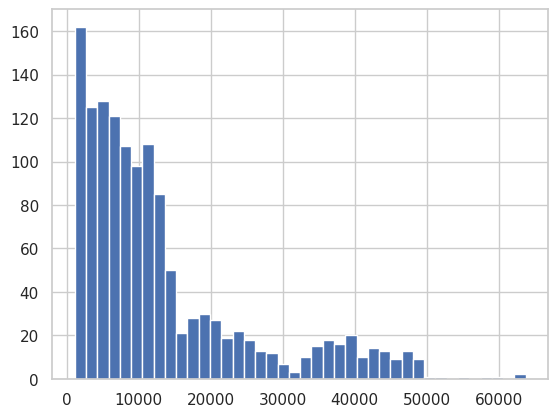

In [4]:
print(df.shape)
df.charges.hist(bins = 40)

In [5]:
df[df.charges > 50000]
df = df[df.charges<50000]

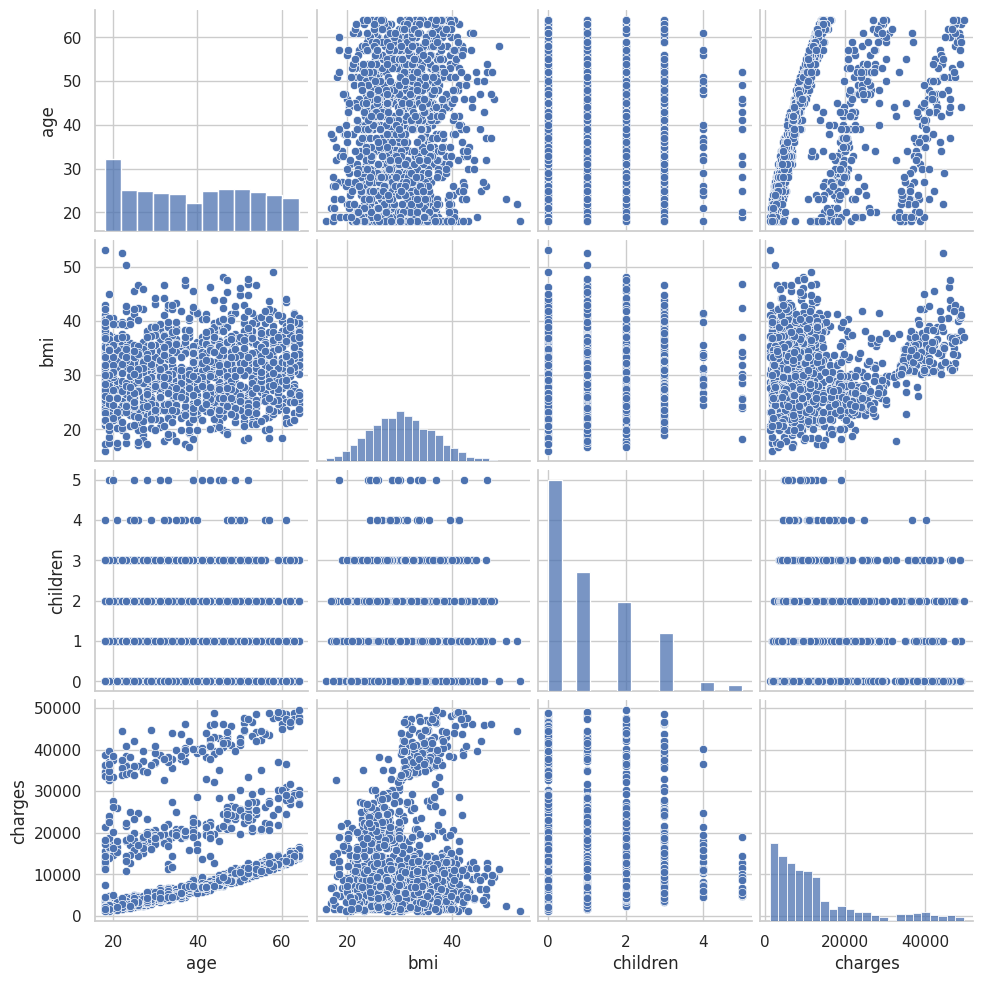

In [6]:
# analisis de correlaciones
import matplotlib.pyplot as plt
sns.pairplot(df, height=2.5)
plt.show()

<Axes: >

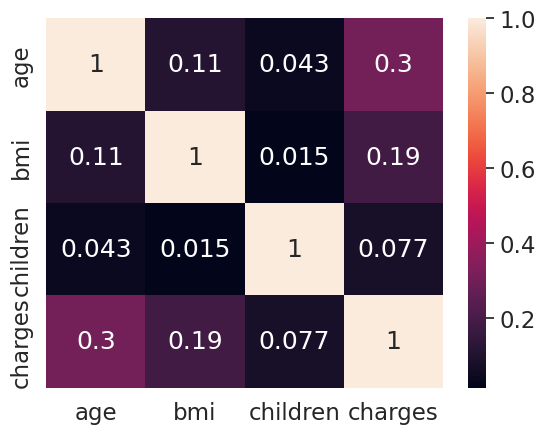

In [7]:
# mapa de calor
import numpy as np
numeric_cols = ['age', 'bmi', 'children', 'charges']
cm = np.corrcoef(df[numeric_cols].values.T)
sns.set(font_scale=1.5)
sns.heatmap(cm, annot=True, yticklabels = numeric_cols, xticklabels = numeric_cols)

In [17]:
#se va a usar la funcion get_dummies para las demas variables categoricas
# pd.get_dummies(df, columns=['sex', 'smoker', 'region'])
# elimna variables redundantes
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first = True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


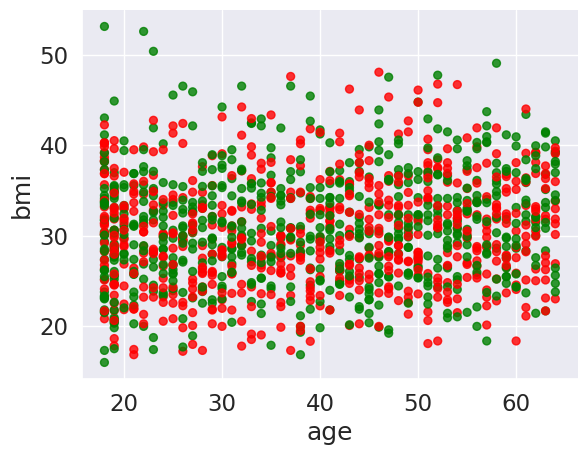

In [22]:
colors = {True: 'green', False: 'red'}

df.plot(kind='scatter', x='age', y='bmi', s=32, alpha=.8, c=df['sex_male'].map(colors))

plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# se va a crear un dataset de prueba y uno de entrenamiento

In [ ]:
# set-> se crea  un tipo de dato, va a eliminar los duplicados pero pierde el orden
# entrenamineto -> ajusta el modelo
# prueba -> evaluar el modelo
x_cols = list(set(df.columns)-set(['charges']))
y_cols = ['charges']

# todos los modelos de sklearn trabajan con arrays de numpy
x = df[x_cols].values
y = df[y_cols].values

# evaluar y entender el modelo
x_train, x_test, y_train, y_test = train_test_split(x,y)

# estandar de los datos
sc_x = StandardScaler().fit(x)
sc_y = StandardScaler().fit(y)

# aplica la transformacion
x_train = sc_x.transform(x_train)
x_test = sc_x.transform(x_test)
y_train = sc_y.transform(y_train)
y_test = sc_y.transform(y_test)

# crear el modelo
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

# cuantos datos predijo
y_pred.shape

(333, 1)

In [ ]:
# importar metricas
import sklearn.metrics as metrics
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
print('mse ', round(mse, 4))
print('r2 ', round(r2, 4))

# exelente modelo >85% de r2



mse  0.2601
r2  0.7338


In [ ]:
# # # from regressors import stats

import statsmodels.api as sm
import numpy as np

x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float).ravel()

x_sm = sm.add_constant(x)
sm_model = sm.OLS(y, x_sm).fit()

print(sm_model.summary())


# modelo con regressors
# model.intercept_ = model.intercept_[0]
# # utilce los coeficientes en una dimension
# model.coef_ = model.coef_.reshape(-1)

# y_test = y_test.reshape(-1)
# print('-------------------RESULTADOS STATS-------------------')
# sm.summary_stats(model, x_test, y_test, x_cols)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     503.4
Date:                Sun, 14 Dec 2025   Prob (F-statistic):               0.00
Time:                        10:45:29   Log-Likelihood:                -13426.
No. Observations:                1331   AIC:                         2.687e+04
Df Residuals:                    1322   BIC:                         2.692e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.129e+04    954.119    -11.832      0.0

In [20]:
import numpy as np

res = model.resid

print("Residuals:")
print(f"Min      {np.min(res):.4f}")
print(f"1Q       {np.percentile(res, 25):.4f}")
print(f"Median   {np.median(res):.4f}")
print(f"3Q       {np.percentile(res, 75):.4f}")
print(f"Max      {np.max(res):.4f}")

Residuals:
Min      -0.9488
1Q       -0.2267
Median   -0.0905
3Q       0.1039
Max      2.0937


In [21]:
import pandas as pd

coef_table = pd.DataFrame({
    "Estimate": model.params,
    "Std. Error": model.bse,
    "t value": model.tvalues,
    "p value": model.pvalues
})

print(coef_table)


   Estimate  Std. Error    t value        p value
0 -0.001200    0.015702  -0.076413   9.391061e-01
1  0.293365    0.015953  18.389226   3.453605e-65
2  0.000571    0.015795   0.036128   9.711875e-01
3  0.065778    0.015815   4.159285   3.469708e-05
4 -0.006699    0.019343  -0.346337   7.291633e-01
5  0.155821    0.016491   9.448704   2.397228e-20
6 -0.026371    0.019227  -1.371584   1.705041e-01
7  0.796539    0.015717  50.679728  3.648708e-277
8 -0.024385    0.020179  -1.208434   2.271691e-01


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     387.8
Date:                Sun, 14 Dec 2025   Prob (F-statistic):          9.80e-299
Time:                        17:10:07   Log-Likelihood:                -711.32
No. Observations:                 998   AIC:                             1441.
Df Residuals:                     989   BIC:                             1485.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0012      0.016     -0.076      0.9

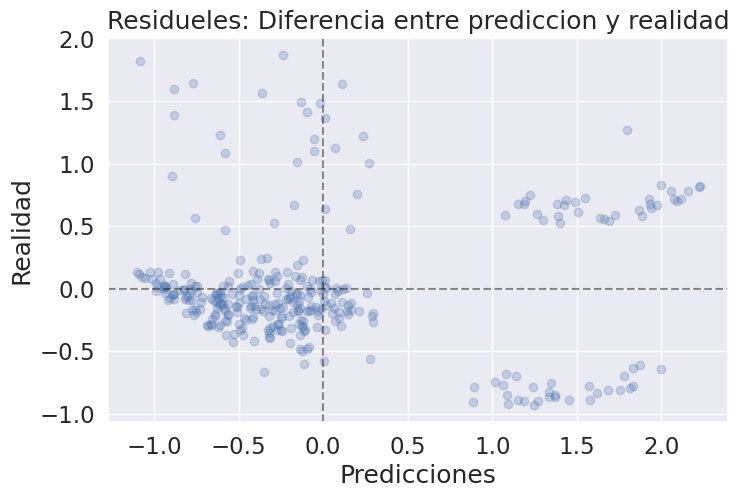

In [ ]:
# CALCUAL RESIDUALES -> ES EL ERROR QUE COMETE EL MODELO EN CADA OBSERVACION, QUE TAN LEJOS ESTUVO DE LA REALIDAD

import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

X_train_sm = sm.add_constant(x_train)
X_test_sm = sm.add_constant(x_test)

results = sm.OLS(y_train, X_train_sm).fit()
print(results.summary())

y_pred = results.predict(X_test_sm)

y_test = np.asarray(y_test).ravel()
y_pred = np.asarray(y_pred).ravel()

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.axvline(x = 0, c='k', ls='--', alpha=0.5)
plt.axhline(y = 0, c='k', ls='--', alpha=0.5)
plt.scatter(y_pred, residuals, alpha=0.25)
plt.xlabel('Predicciones')
plt.ylabel('Realidad')
plt.title('Residueles: Diferencia entre prediccion y realidad')
plt.show()


In [40]:
# crea nuevas variables y eliminar v para mejorar el modelo
df_second = df.copy()

# asi se eleva la edad al 2
df_second['age2'] = df_second.age**2
# que lo ponga como entero 
df_second['sobrepeso'] = (df_second.bmi >= 30).astype(int)
df_second['sobrepeso*fumador'] = df_second.sobrepeso * df_second.smoker_yes

In [51]:
# CREAR MODELO
# x_cols = list(set(df_second.columns)-set(['charges']))
x_cols = ['sobrepeso*fumador', 'smoker_yes', 'age2', 'age', 'children']
y_cols = ['charges']

# todos los modelos de sklearn trabajan con arrays de numpy
x = df_second[x_cols].values
y = df_second[y_cols].values

# evaluar y entender el modelo
x_train, x_test, y_train, y_test = train_test_split(x,y)

# estandar de los datos
sc_x = StandardScaler().fit(x)
sc_y = StandardScaler().fit(y)

# aplica la transformacion
x_train = sc_x.transform(x_train)
x_test = sc_x.transform(x_test)
y_train = sc_y.transform(y_train)
y_test = sc_y.transform(y_test)

# crear el modelo
model = LinearRegression(fit_intercept=False)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

# cuantos datos predijo
y_pred.shape

(333, 1)

In [52]:
# METRICAS-> ANALISIS

import sklearn.metrics as metrics
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
print('mse ', round(mse, 4))
print('r2 ', round(r2, 4))

mse  0.1079
r2  0.8958


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     1145.
Date:                Sun, 14 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:55:14   Log-Likelihood:                -455.57
No. Observations:                 998   AIC:                             923.1
Df Residuals:                     992   BIC:                             952.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0065      0.012      0.533      0.5

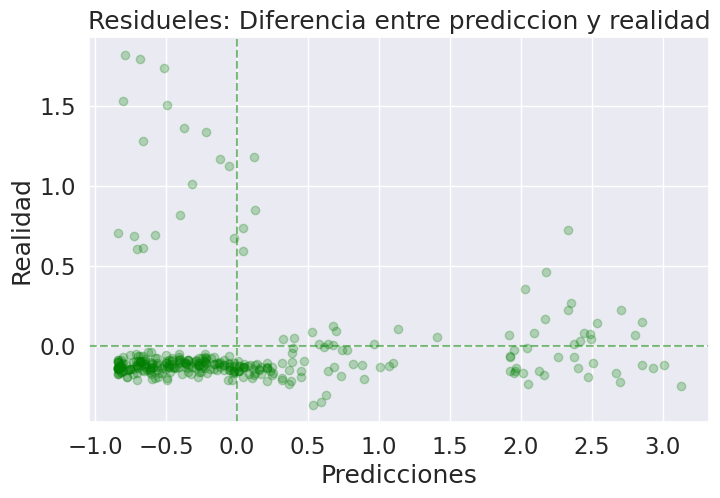

R²: 0.8523307170333977
R² ajustado: 0.8515864162119935


In [53]:

import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

X_train_sm = sm.add_constant(x_train)
X_test_sm = sm.add_constant(x_test)

results = sm.OLS(y_train, X_train_sm).fit()
print(results.summary())

y_pred = results.predict(X_test_sm)

y_test = np.asarray(y_test).ravel()
y_pred = np.asarray(y_pred).ravel()

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.axvline(x = 0, c='green', ls='--', alpha=0.5)
plt.axhline(y = 0, c='green', ls='--', alpha=0.5)
plt.scatter(y_pred, residuals, alpha=0.25, color='green')
plt.xlabel('Predicciones')
plt.ylabel('Realidad')
plt.title('Residueles: Diferencia entre prediccion y realidad')
plt.show()

print("R²:", results.rsquared)
print("R² ajustado:", results.rsquared_adj)
